In [2]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Make model/ and parameter_scan/ importable (if running from parameter_scan/)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('../.'))

from xso.parscans import run_xso_parscan, run_xso_stabilityscan

#from cariaco_ssm_setup import model, model_setup, model_setup_slim, phyto_esd, zoo_esd
from cariaco_obs import load_cariaco_targets
from parscan_utils import (
    compute_cost_grid, find_best_fit, get_default_from_setup,
)

from taniguchi_setup import model, model_setup

In [3]:
with model:
    output = model_setup.xsimlab.run()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

Text(0.5, 1.0, 'Phytoplankton P(s, t)')

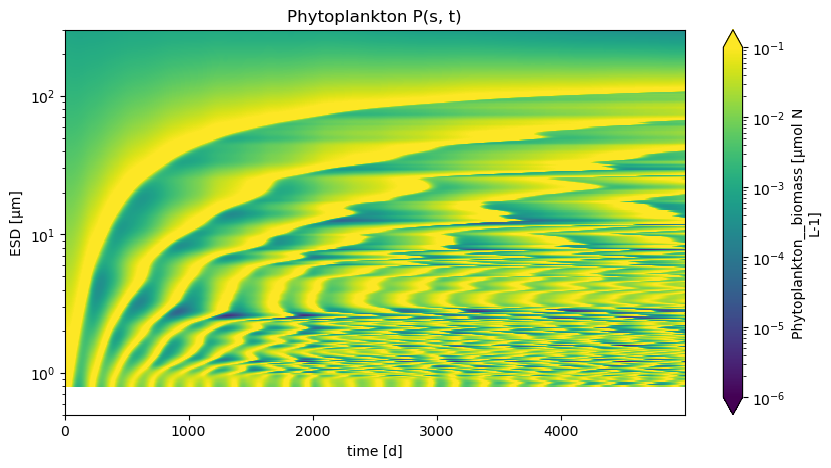

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
output.Phytoplankton__biomass.where(output.Phytoplankton__biomass > 0).plot(
    x='time', y='phyto', ax=ax,
    norm=mcolors.LogNorm(vmin=1e-6, vmax=0.1), cmap='viridis')
ax.set_yscale('log')
ax.set_ylim(0.5, 300)
ax.set_ylabel('ESD [µm]')
ax.set_title('Phytoplankton P(s, t)')

Text(0.5, 1.0, 'Microzooplankton Z(s, t)')

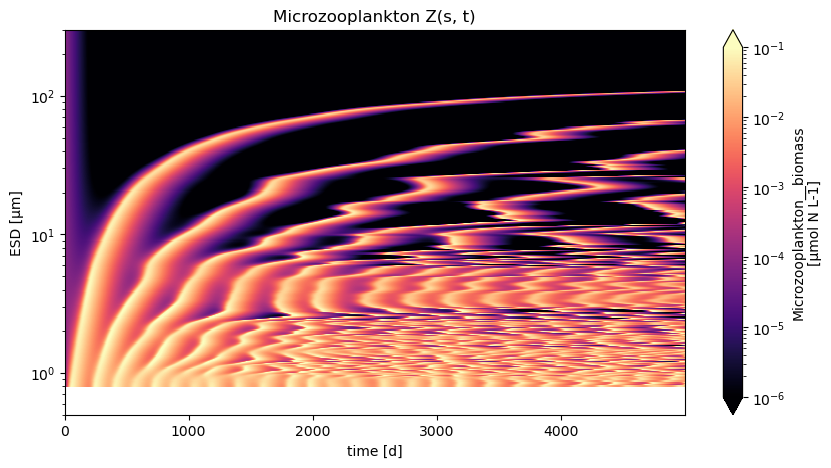

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
output.Microzooplankton__biomass.plot(
    x='time', y='zoo', ax=ax,
    norm=mcolors.LogNorm(vmin=1e-6, vmax=0.1), cmap='magma')
ax.set_yscale('log')
ax.set_ylim(0.5, 300)
ax.set_ylabel('ESD [µm]')
ax.set_title('Microzooplankton Z(s, t)')

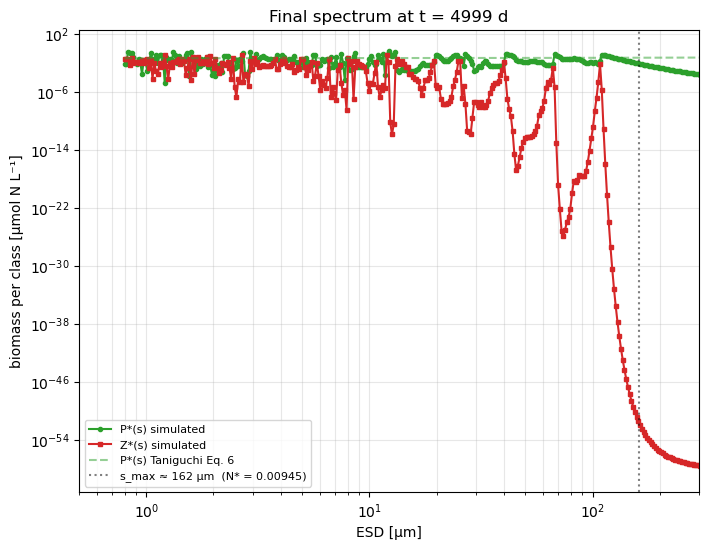

In [7]:
P_final = output.Phytoplankton__biomass.isel(time=-1)
Z_final = output.Microzooplankton__biomass.isel(time=-1)
s = P_final.phyto.values

# Taniguchi Eq. 6:  P*(s) = Δ k_z(s) / (Γ g(s) − Δ)
g_max = 33.96 * s**(-0.66)
k_z   = 17.92 * s**(-0.64)
P_anal = np.where(0.31*g_max - 0.025 > 0,
                  0.025 * k_z / (0.31*g_max - 0.025), np.nan)

# Eq. 12 viability extent at the simulated steady-state N
N_ss  = float(output.Nutrient__value.isel(time=-1))
s_max = (1.36 * N_ss / (0.0015 * 0.33))**(1/0.64)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(s, P_final, 'o-', color='C2', ms=3, label='P*(s) simulated')
ax.loglog(Z_final.zoo, Z_final, 's-', color='C3', ms=3, label='Z*(s) simulated')
ax.loglog(s, P_anal, '--', color='C2', alpha=0.5, label='P*(s) Taniguchi Eq. 6')
ax.axvline(s_max, color='k', ls=':', alpha=0.5,
           label=f's_max ≈ {s_max:.0f} µm  (N* = {N_ss:.3g})')
ax.set(xlabel='ESD [µm]', ylabel='biomass per class [µmol N L⁻¹]',
       xlim=(0.5, 300), title=f'Final spectrum at t = {float(P_final.time):.0f} d')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, which='both', alpha=0.3)

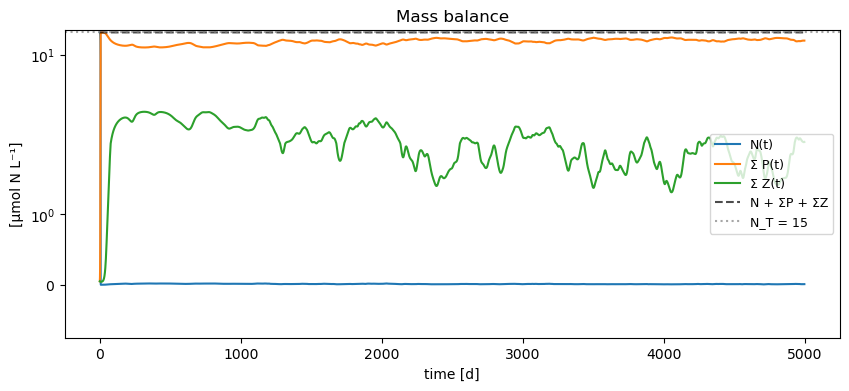

In [8]:
N     = output.Nutrient__value
P_sum = output.Phytoplankton__biomass.sum(dim='phyto')
Z_sum = output.Microzooplankton__biomass.sum(dim='zoo')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(N.time, N,     label='N(t)')
ax.plot(N.time, P_sum, label='Σ P(t)')
ax.plot(N.time, Z_sum, label='Σ Z(t)')
ax.plot(N.time, N + P_sum + Z_sum, 'k--', alpha=0.7, label='N + ΣP + ΣZ')
ax.axhline(15, color='gray', ls=':', alpha=0.7, label='N_T = 15')
ax.set(xlabel='time [d]', ylabel='[µmol N L⁻¹]',
       yscale='symlog', title='Mass balance')
ax.legend(fontsize=9, loc='center right')

In [12]:
# --- Build steady-state seed from tail mean of the IVP run ---
AVG_WINDOW = 1000
FLOOR      = 1e-10   # strict positivity for fsolve

N_seed = float(output.Nutrient__value
               .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
P_seed = (output.Phytoplankton__biomass
          .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
Z_seed = (output.Microzooplankton__biomass
          .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

n_P_floored = int(np.sum(P_seed < FLOOR))
n_Z_floored = int(np.sum(Z_seed < FLOOR))
N_seed = max(N_seed, FLOOR)
P_seed = np.maximum(P_seed, FLOOR)
Z_seed = np.maximum(Z_seed, FLOOR)

print(f"Seed (last {AVG_WINDOW} d mean, floor = {FLOOR}):")
print(f"  N_seed   = {N_seed:.6g}")
print(f"  Σ P_seed = {P_seed.sum():.6g}   ({n_P_floored}/{len(P_seed)} entries at floor)")
print(f"  Σ Z_seed = {Z_seed.sum():.6g}   ({n_Z_floored}/{len(Z_seed)} entries at floor)")
print(f"  closure  = {N_seed + P_seed.sum() + Z_seed.sum():.6g}   (expect ~15.0)")

Seed (last 1000 d mean, floor = 1e-10):
  N_seed   = 0.00948808
  Σ P_seed = 13.1947   (0/501 entries at floor)
  Σ Z_seed = 1.79581   (248/501 entries at floor)
  closure  = 15   (expect ~15.0)


In [14]:
# --- Run stability solver seeded from the tail mean ---
from taniguchi_setup import model_setup_stability

with model:
    result_ss = (model_setup_stability
                 .xsimlab.update_vars(input_vars={
                     'Nutrient':         {'value_init':   N_seed},
                     'Phytoplankton':    {'biomass_init': P_seed},
                     'Microzooplankton': {'biomass_init': Z_seed},
                 })
                 .xsimlab.run())

# Steady state stored at time=-1 (XSO stability-solver convention)
N_star = float(result_ss.Nutrient__value.isel(time=-1).values)
P_star = result_ss.Phytoplankton__biomass.isel(time=-1).values
Z_star = result_ss.Microzooplankton__biomass.isel(time=-1).values

print(f"Steady state (fsolve):")
print(f"  N*       = {N_star:.6g}")
print(f"  Σ P*     = {P_star.sum():.6g}")
print(f"  Σ Z*     = {Z_star.sum():.6g}")
print(f"  closure  = {N_star + P_star.sum() + Z_star.sum():.6g}   (expect ~15.0)")

print()
for name in ('stability', 'max_eigenvalue', 'n_positive_eigenvalues'):
    if name in result_ss:
        print(f"  {name:23s}: {result_ss[name].values}")

[INFO] Initial state dimension: 1003
[INFO] Initial state: [9.48807631e-03 4.53984639e-02 4.53410319e-02 ... 1.00000000e-10
 1.00000000e-10 1.00000000e-10]
[INFO] Steady state found with residual norm: 1.74e-14
  Steady state: [ 9.35948829e-03  4.24523213e-02  4.24686822e-02 ... -1.05537090e-45
  8.58510799e-47  1.00795140e-46]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 1003 eigenvalues
Steady state (fsolve):
  N*       = 0.00935949
  Σ P*     = 10.0664
  Σ Z*     = 1.69766
  closure  = 11.7734   (expect ~15.0)



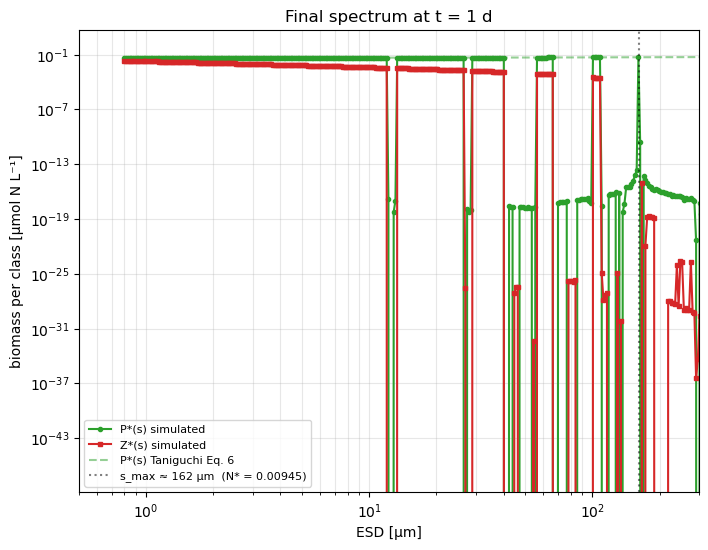

In [18]:
P_final = result_ss.Phytoplankton__biomass.isel(time=-1)
Z_final = result_ss.Microzooplankton__biomass.isel(time=-1)
s = P_final.phyto.values

# Taniguchi Eq. 6:  P*(s) = Δ k_z(s) / (Γ g(s) − Δ)
g_max = 33.96 * s**(-0.66)
k_z   = 17.92 * s**(-0.64)
P_anal = np.where(0.31*g_max - 0.025 > 0,
                  0.025 * k_z / (0.31*g_max - 0.025), np.nan)

# Eq. 12 viability extent at the simulated steady-state N
N_ss  = float(output.Nutrient__value.isel(time=-1))
s_max = (1.36 * N_ss / (0.0015 * 0.33))**(1/0.64)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(s, P_final, 'o-', color='C2', ms=3, label='P*(s) simulated')
ax.loglog(Z_final.zoo, Z_final, 's-', color='C3', ms=3, label='Z*(s) simulated')
ax.loglog(s, P_anal, '--', color='C2', alpha=0.5, label='P*(s) Taniguchi Eq. 6')
ax.axvline(s_max, color='k', ls=':', alpha=0.5,
           label=f's_max ≈ {s_max:.0f} µm  (N* = {N_ss:.3g})')
ax.set(xlabel='ESD [µm]', ylabel='biomass per class [µmol N L⁻¹]',
       xlim=(0.5, 300), title=f'Final spectrum at t = {float(P_final.time):.0f} d')
ax.legend(fontsize=8, loc='lower left')
ax.grid(True, which='both', alpha=0.3)

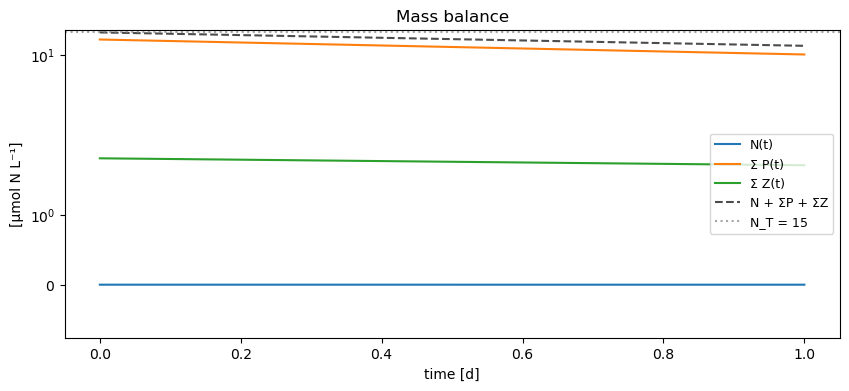

In [15]:
N     = result_ss.Nutrient__value
P_sum = result_ss.Phytoplankton__biomass.sum(dim='phyto')
Z_sum = result_ss.Microzooplankton__biomass.sum(dim='zoo')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(N.time, N,     label='N(t)')
ax.plot(N.time, P_sum, label='Σ P(t)')
ax.plot(N.time, Z_sum, label='Σ Z(t)')
ax.plot(N.time, N + P_sum + Z_sum, 'k--', alpha=0.7, label='N + ΣP + ΣZ')
ax.axhline(15, color='gray', ls=':', alpha=0.7, label='N_T = 15')
ax.set(xlabel='time [d]', ylabel='[µmol N L⁻¹]',
       yscale='symlog', title='Mass balance')
ax.legend(fontsize=9, loc='center right')

In [19]:
print(list(result_ss.))

['Core__solver_type', 'Grazing__g_max', 'Grazing__gain_zoo_value', 'Grazing__gamma', 'Grazing__k_z', 'Grazing__loss_phyto_value', 'Grazing__nutrient', 'Grazing__predator', 'Grazing__prey', 'Grazing__recycle_to_N_value', 'Growth__consumer', 'Growth__halfsat', 'Growth__mu_max', 'Growth__resource', 'Growth__uptake_value', 'Microzooplankton__biomass', 'Microzooplankton__biomass_init', 'Microzooplankton__biomass_label', 'Microzooplankton__zoo_esd_index', 'Microzooplankton__zoo_esd_label', 'Nutrient__value', 'Nutrient__value_init', 'Nutrient__value_label', 'PhytoLoss__mortality_value', 'PhytoLoss__nutrient', 'PhytoLoss__population', 'PhytoLoss__rate', 'PhytoLoss__recycle_to_N_value', 'Phytoplankton__biomass', 'Phytoplankton__biomass_init', 'Phytoplankton__biomass_label', 'Phytoplankton__phyto_esd_index', 'Phytoplankton__phyto_esd_label', 'Time__time_input', 'ZooLoss__mortality_value', 'ZooLoss__nutrient', 'ZooLoss__population', 'ZooLoss__rate', 'ZooLoss__recycle_to_N_value']


In [20]:
# --- Run stability solver seeded from the tail mean, with eigenvalue hook ---
from taniguchi_setup import model_setup_stability
from xso.parscans import StabilityAnalysisHook

hook = StabilityAnalysisHook()

with model:
    result_ss = (model_setup_stability
                 .xsimlab.update_vars(input_vars={
                     'Nutrient':         {'value_init':   N_seed},
                     'Phytoplankton':    {'biomass_init': P_seed},
                     'Microzooplankton': {'biomass_init': Z_seed},
                 })
                 .xsimlab.run(hooks=[hook]))

stability_data = hook.get_results()

# Steady state stored at time=-1 (XSO stability-solver convention)
N_star = float(result_ss.Nutrient__value.isel(time=-1).values)
P_star = result_ss.Phytoplankton__biomass.isel(time=-1).values
Z_star = result_ss.Microzooplankton__biomass.isel(time=-1).values

print(f"\nSteady state (fsolve):")
print(f"  N*       = {N_star:.6g}")
print(f"  Σ P*     = {P_star.sum():.6g}")
print(f"  Σ Z*     = {Z_star.sum():.6g}")
print(f"  closure  = {N_star + P_star.sum() + Z_star.sum():.6g}   (expect ~15.0)")

print(f"\nEigenvalue analysis:")
print(f"  stability              : {stability_data.get('stability')}")
print(f"  max eigenvalue (real)  : {stability_data.get('max_eigenvalue_real'):.4e}")
print(f"  n positive eigenvalues : {stability_data.get('n_positive_eigenvalues')}")
print(f"  n complex pairs        : {stability_data.get('n_complex_pairs')}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[INFO] Initial state dimension: 1003
[INFO] Initial state: [9.48807631e-03 4.53984639e-02 4.53410319e-02 ... 1.00000000e-10
 1.00000000e-10 1.00000000e-10]
[INFO] Steady state found with residual norm: 1.74e-14
  Steady state: [ 9.35948829e-03  4.24523213e-02  4.24686822e-02 ... -1.05537090e-45
  8.58510799e-47  1.00795140e-46]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 1003 eigenvalues
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 6.2200e-03

Steady state (fsolve):
  N*       = 0.00935949
  Σ P*     = 10.0664
  Σ Z*     = 1.69766
  closure  = 11.7734   (expect ~15.0)

Eigenvalue analysis:
  stability              : unstable
  max eigenvalue (real)  : 6.2200e-03
  n positive eigenvalues : 509
  n complex pairs        : 223
